In [1]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../dataset/clean_dataset_sample.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (300000, 81)


,Source Port,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,-1.341583,-0.425284,1.437675,-0.461085,-0.009935,-0.008393,-0.042407,-0.007051,-0.215421,0.422018,...,0.002268,-0.128428,-0.101914,-0.150163,-0.105006,-0.380578,-0.11786,-0.386236,-0.366398,0
1,0.676922,-0.423729,-0.694018,-0.313729,-0.008441,-0.009510,-0.050861,-0.007183,-0.273999,-0.271856,...,0.002278,-0.128428,-0.101914,-0.150163,-0.105006,-0.380578,-0.11786,-0.386236,-0.366398,0
2,-1.194689,-0.423729,-0.694018,-0.460889,-0.009935,-0.010627,-0.049758,-0.007183,-0.266359,-0.181351,...,0.002268,-0.128428,-0.101914,-0.150163,-0.105006,-0.380578,-0.11786,-0.386236,-0.366398,0
3,-0.063102,-0.388536,-0.694018,-0.461985,-0.009935,-0.010627,-0.050493,-0.007183,-0.271452,-0.241688,...,0.002272,-0.128428,-0.101914,-0.150163,-0.105006,-0.380578,-0.11786,-0.386236,-0.366398,0
4,0.843306,-0.402821,-0.694018,-0.456820,-0.002467,-0.005042,-0.016309,-0.005445,-0.018039,-0.271856,...,0.002268,-0.128428,-0.101914,-0.150163,-0.105006,-0.380578,-0.11786,-0.386236,-0.366398,0


In [3]:
X = df.drop("Label", axis=1)

y = df["Label"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(240000, 80)
(60000, 80)


In [6]:
iso_model = IsolationForest(
    n_estimators=200,
    contamination="auto",
    random_state=42,
    n_jobs=-1
)

X_train_normal = X_train[y_train == 0]

iso_model.fit(X_train_normal)

print("Isolation Forest Trained Successfully!")

Isolation Forest Trained Successfully!


In [7]:
pred = iso_model.predict(X_test)

pred = np.where(pred == 1, 0, 1)

In [8]:
print("Accuracy :", accuracy_score(y_test, pred))

print("Precision :", precision_score(y_test, pred))

print("Recall :", recall_score(y_test, pred))

print("F1 Score :", f1_score(y_test, pred))

Accuracy : 0.7939166666666667
Precision : 0.6496196498946017
Recall : 0.45348688419705696
F1 Score : 0.5341170264873215


In [9]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.83      0.91      0.87     44370
           1       0.65      0.45      0.53     15630

    accuracy                           0.79     60000
   macro avg       0.74      0.68      0.70     60000
weighted avg       0.78      0.79      0.78     60000



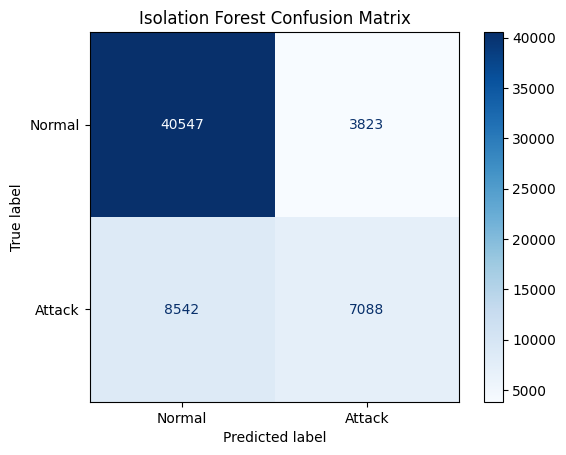

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Attack"]
)

disp.plot(cmap="Blues")

plt.title("Isolation Forest Confusion Matrix")
plt.show()

In [13]:
joblib.dump(
    iso_model,
    "../models/isolation_forest.pkl"
)

print("Isolation Forest Model Saved!")

Isolation Forest Model Saved!


In [3]:
import matplotlib.pyplot as plt
plt.savefig(
    "../results/isolation_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

<Figure size 640x480 with 0 Axes>

In [14]:
loaded_model = joblib.load("../models/isolation_forest.pkl")

sample = X.iloc[:5]

prediction = loaded_model.predict(sample)

prediction = np.where(prediction == 1, 0, 1)

print(prediction)

[0 0 0 0 0]
